<a href="https://colab.research.google.com/github/digvijaylp/SBMtutorial1/blob/main/SBM_tutorial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenSMOG Molecular Dynamics Simulation
###This notebook initializes and runs a structure-based molecular dynamics simulation using `OpenSMOG`.



## 1. Installing Packages
<br>
(A) SuBMIT: For generating coarse-grained SBM structure and forcefield files.<br>
(B) OpenMM: MD integrator.<br>
(C) OpenSMOG: OpenMM based SBM MD package.<br>
(D) MDTraj: For analyzing MD trajectory.<br>


In [1]:
!git clone https://github.com/sglabncbs/SuBMIT
%cd /content/SuBMIT/
!pip install .


Cloning into 'SuBMIT'...
remote: Enumerating objects: 1119, done.
remote: Counting objects: 100% (218/218), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 1119 (delta 94), reused 190 (delta 78), pack-reused 901 (from 2)
Receiving objects: 100% (1119/1119), 2.90 MiB | 11.10 MiB/s, done.
Resolving deltas: 100% (555/555), done.
/content/SuBMIT
Processing /content/SuBMIT
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 79.6 MB/s eta 0:00:00
  Created wheel for SuBMIT: filename=submit-1.0.0-py3-none-any.whl size=139076 sha256=6ddacd573dc9f489674af9afa7137e78e9178ca152aa10dc59cf77672b90bd02
  Stored in directory: /tmp/pip-ephem-wheel-cache-2qrb1z7w/wheels/7f/61/9c/ff2629dbe82e397d3411920e6dc1e7cc7b009fff366300d302
Successfully built SuBMIT
  Attempt

In [1]:
!pip install openmm[cuda12] opensmog mdtraj py3Dmol


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 104.4 MB/s eta 0:00:00
  Created wheel for opensmog: filename=opensmog-1.3-py3-none-any.whl size=1994490 sha256=ac395b846e733ee0465f1ae3c31651ac1e37b714ab123db71b3919d31cda0361
  Stored in directory: /root/.cache/pip/wheels/e9/15/1e/e04da1d42fe3bbb17463c782706325faa1063c45cf34bbf20b
Successfully built opensmog


## 2. Generating C-alpha SBM files
###For C-alpha SBM simulations of 2CI2. <br><br>



###2.1 Run SuBMIT for 2CI2.pdb.


In [2]:
# Go to examples directory
%cd /content/SuBMIT/examples/Clementi2000_CA-model/Default_LJ1012_contacts/OpenSMOG/
# Run submit-cli command with input pdb (--aa_pdb), SBM variant (--calpha_sbm) and tool type (--opensmog)
!submit-cli --aa_pdb 2CI2.pdb --calpha_sbm --opensmog


/content/SuBMIT/examples/Clementi2000_CA-model/Default_LJ1012_contacts/OpenSMOG
>>> Using Clementi et. al. 2000 CA-only model. 10.1006/jmbi.2000.3693
>>non-bond function --nbfunc not given. Using 2.
>>> Renumbering atoms. 
>>> The chain_id and residue number remains same, 2CI2.pdb
Unrecognised residue name HOH 84 . Skipping. This might add a chain terminal!!!
Unrecognised residue name HOH 85 . Skipping. This might add a chain terminal!!!
Unrecognised residue name HOH 86 . Skipping. This might add a chain terminal!!!
Unrecognised residue name HOH 87 . Skipping. This might add a chain terminal!!!
Unrecognised residue name HOH 88 . Skipping. This might add a chain terminal!!!
Unrecognised residue name HOH 89 . Skipping. This might add a chain terminal!!!
Unrecognised residue name HOH 90 . Skipping. This might add a chain terminal!!!
Unrecognised residue name HOH 91 . Skipping. This might add a chain terminal!!!
Unrecognised residue name HOH 92 . Skipping. This might add a chain terminal!!

###2.2 View struture and plot native contact map.






In [3]:
import numpy as np
import matplotlib.pyplot as plt
import py3Dmol
import ipywidgets as widgets
from IPython.display import display

!ls 2CI2.pdb
# load and show 2CI2 structure
with open('2CI2.pdb','r') as fin:
    pdb_data = fin.read()
viewer = py3Dmol.view(width=500, height=500)
viewer.addModel(pdb_data, 'pdb')
viewer.setStyle({'cartoon': {'color': 'spectrum'}})
viewer.zoomTo()
struct_output = widgets.Output()
with struct_output:
  viewer.show()

# load and plot 2CI2 native contact map
!ls SuBMIT_Output/RenumberedPDB_CMap/prot.CGcont
with open('SuBMIT_Output/RenumberedPDB_CMap/prot.CGcont','r') as fin:
  C1,A1,C2,A2,W,D=np.transpose([l.split() for l in fin])
  A1,A2=np.intp([A1,A2])
  D=np.float64(D)
fig,ax=plt.subplots(1,1,figsize=(5.5, 5.5))
ax.set_aspect('1')
plot_output = widgets.Output()
plt.scatter(x=A1,y=A2,marker='s',s=10)
plt.scatter(x=A2,y=A1,marker='s',s=10)
plt.title("2CI2 Native Contact Map")
plt.xlabel("Residue number")
plt.ylabel("Residue number")

with plot_output:
  plt.show()

side_by_side_layout = widgets.HBox([struct_output,plot_output])
display(side_by_side_layout)



2CI2.pdb
SuBMIT_Output/RenumberedPDB_CMap/prot.CGcont


###2.3 Download SuBMIT_Output directory.




In [ ]:
!ls SuBMIT_Output/
!zip -r SuBMIT_Output.zip SuBMIT_Output/

from google.colab import files
files.download("SuBMIT_Output.zip")

GRO_TOP_XML   molecule_order.list  opensmog.top  RenumberedPDB_CMap
model_params  opensmog.gro	   opensmog.xml  Tables
updating: SuBMIT_Output/ (stored 0%)
updating: SuBMIT_Output/molecule_order.list (deflated 24%)
updating: SuBMIT_Output/opensmog.gro (deflated 68%)
updating: SuBMIT_Output/RenumberedPDB_CMap/ (stored 0%)
updating: SuBMIT_Output/RenumberedPDB_CMap/2CI2.renum.pdb (deflated 74%)
updating: SuBMIT_Output/RenumberedPDB_CMap/prot.CGcont (deflated 80%)
updating: SuBMIT_Output/RenumberedPDB_CMap/prot.AAcont (deflated 88%)
updating: SuBMIT_Output/RenumberedPDB_CMap/2CI2.renum.prot.native_CA.pdb (deflated 66%)
updating: SuBMIT_Output/opensmog.xml (deflated 84%)
updating: SuBMIT_Output/Tables/ (stored 0%)
updating: SuBMIT_Output/GRO_TOP_XML/ (stored 0%)
updating: SuBMIT_Output/GRO_TOP_XML/prot_opensmog.top (deflated 80%)
updating: SuBMIT_Output/GRO_TOP_XML/prot_opensmog.gro (deflated 66%)
updating: SuBMIT_Output/GRO_TOP_XML/prot_opensmog.xml (deflated 84%)
updating: SuBMIT_Output/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Running SBM simulations

###3.1 Loading OpenSMOG python module

In [4]:
from OpenSMOG import SBM


    ****************************************************************************************    
       **** *** *** *** *** *** *** *** OpenSMOG (v1.3) *** *** *** *** *** *** *** ****        

           The OpenSMOG class is used to perform molecular dynamics simulations using           
                     Structure-Based Models (SBM) for biomolecular systems,                     
             and it allows for the simulation of a wide variety of potential forms.             
                      OpenSMOG uses force field files generated by SMOG 2.                      
                             OpenSMOG documentation is available at                             
                  https://opensmog.readthedocs.io and https://smog-server.org                   

                    OpenSMOG is described in: Oliveira and Contessoto et al,                    
              SMOG 2 and OpenSMOG: Extending the limits of structure-based models.              
                    Protein 

##3.2 Setting up simulation parameters

In [31]:
simul_prefix = "Output"   # Output file prefix
dt = 0.0005               # time step in reduced time units (here picoseconds)
collision_rate = 1.0      # inverse time units (here ps^-1)
r_cutoff = 1.1            # nonbond interaction cutoff (in nm)
T = 0.96                  # Temperature in reduced units
report_interval=2000      # Write out after every 2000 steps
sbm_CA = SBM(name=simul_prefix,
             time_step=dt,
             collision_rate=collision_rate,
             r_cutoff=r_cutoff,
             temperature=T,
             pbc=True)    # Create simulation object


##3.3 Setting up simulation platform



In [6]:

# Setup OpenMM platform (cuda, HIP, opencl, or cpu)
sbm_CA.setup_openmm(platform='cuda', GPUindex='default')



##3.4 Loading SuBMIT generated CG structure and forcefield files

In [10]:
!ls SuBMIT_Output/opensmog.*
# file names
sbm_CA_grofile = "SuBMIT_Output/opensmog.gro"
sbm_CA_topfile = "SuBMIT_Output/opensmog.top"
sbm_CA_xmlfile = "SuBMIT_Output/opensmog.xml"
# Load files
sbm_CA.loadSystem(Grofile=sbm_CA_grofile, Topfile=sbm_CA_topfile, Xmlfile=sbm_CA_xmlfile)



SuBMIT_Output/opensmog.gro  SuBMIT_Output/opensmog.xml
SuBMIT_Output/opensmog.top


NOTE: loadSystem WAS ALREADY CALLED.  THE SYSTEM (FORCE FIELD PARAMETERS) WILL BE OVERWRITTEN. CALLING loadSystem MULTIPLE TIMES IS NOT RECOMMENDED, SINCE IT CAN LEAD TO UNPREDICTABLE BEHAVIOR.


Will try to load coordinates from SuBMIT_Output/opensmog.gro
    65 atoms loaded from gro file
Will try to load force field from SuBMIT_Output/opensmog.top
This simulation will use periodic boundary conditions
    65 atoms loaded from top file
Will try to load OpenSMOG-specific force field terms from SuBMIT_Output/opensmog.xml
Contacts found in the xml file.  Will include definitions
provided in the top and xml files.

Nonbonded parameters found in XML file. Nonbonded
parameters in top file will be ignored.

Dihedral definitions not found in XML file. Will only 
use dihedral information provided in the top file.


Angles definitions not found in XML file. Will only 
use angles information provided in the top fi

##3.5 Create simulation context and setup energy, force and coordinates reporters

In [8]:

# create simulation context
outdir = "T%.2f" % T
sbm_CA.saveFolder(outdir)
sbm_CA.createSimulation()
# Setup reporters
trjformat = "xtc"
sbm_CA.createReporters(trajectory=True, trajectoryFormat=trjformat,
                       energies=True, energy_components=True,
                       interval=report_interval)


Will try to load coordinates from SuBMIT_Output/opensmog.gro
    65 atoms loaded from gro file
Will try to load force field from SuBMIT_Output/opensmog.top
This simulation will use periodic boundary conditions
    65 atoms loaded from top file
Will try to load OpenSMOG-specific force field terms from SuBMIT_Output/opensmog.xml
Contacts found in the xml file.  Will include definitions
provided in the top and xml files.

Nonbonded parameters found in XML file. Nonbonded
parameters in top file will be ignored.

Dihedral definitions not found in XML file. Will only 
use dihedral information provided in the top file.


Angles definitions not found in XML file. Will only 
use angles information provided in the top file.

Contact force prot_contacts0_LJ-10-12 read from xml file

Nonbonded force 0 read from xml file.
        This will replace any nonbonded definitions given in the .top file


Loaded force field and config files.
Creating the simulation with the following parameters:
        na

##3.6 Run simulation


In [ ]:
# Run MD production steps
sbm_CA.run(nsteps=5000000, report=True, interval=10000)

##

# 4. Analysis

## 4.0 Loading the trajectory

In [39]:
# check for trajectory
!ls T0.96/Output_trajectory.xtc

import mdtraj as md

# load trajectory
sbm_CA_trjfile='T0.96/Output_trajectory.xtc'
traj=md.load(sbm_CA_trjfile,top=sbm_CA_grofile)

print (traj)
sim_time=traj.time  # simulation time
sim_steps=sim_time/dt # simulation steps time/dt



T0.96/Output_trajectory.xtc
<mdtraj.Trajectory with 2500 frames, 65 atoms, 65 residues, and unitcells>


## 4.1 Radius of gyration

Rg-array-shape: (2500,)
time-array-shape: (2500,)


Text(0.5, 1.0, 'Radius of Gyration')

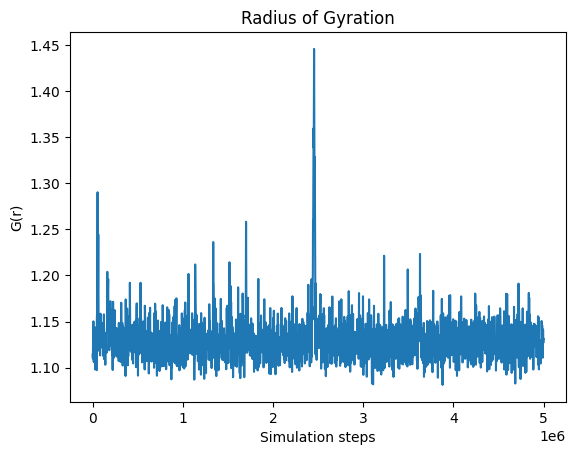

In [57]:


# compute radius of gyration
Rg=md.compute_rg(traj=traj)

print ("Rg-array-shape:",Rg.shape)
print ("time-array-shape:",time.shape)

plt.plot(sim_steps,Rg)
plt.xlabel("Simulation steps")
plt.ylabel("G(r)")
plt.title("Radius of Gyration")


## 4.2 Fraction native contacts

In [2]:
# native contact map file
with open('SuBMIT_Output/RenumberedPDB_CMap/prot.CGcont','r') as fin:
  C1,A1,C2,A2,W,D=np.transpose([l.split() for l in fin])

# -1 to start atom index from 0
native_pairs=-1+np.intp([A1,A2]).T
# *0.1 to convert to nm
native_dists=0.1*np.float64(D)
print ("Shape of contact-map pairs array:",native_pairs.shape)
print ("Shape of contact-map distances array:",native_dists.shape)
total_contacts=native_dists.shape[0]


# calculate native pair distances in each frame
dists=md.compute_distances(traj=traj,periodic=True,atom_pairs=native_pairs)

# determing pairs which are 1.2*native distance in each frame
contacting_pairs=np.intp(dists<=1.2*native_dists) # 1 is contactsing, else 0

print ("Distance array shape (No.of.frames x No.of.pairs):",dists.shape)
print ("Contacting pairs array shape (No.of.frames x No.of.pairs):",dists.shape)

# total no. of contacting pairs (1s) per frame
Q=np.sum(contacting_pairs,1)
# convert to percent contacting native pairs (foldedness)
Q_percent=100*Q/total_contacts

print ("Q array shape (same as no.of.frames):",Q.shape)
plt.plot(sim_steps,Q_percent)
plt.xlabel("Simulation steps")
plt.ylabel("Folded-ness Q")
plt.title("Fraction native contacts")

FileNotFoundError: [Errno 2] No such file or directory: 'SuBMIT_Output/RenumberedPDB_CMap/prot.CGcont'

## 4.3 Free energy as a function of Q

In [1]:
print ("Q array shape (same as no.of.frames):",Q.shape)

n_bins=10
# 1-D array for Q-values (same as prev snippet)
bin_boundaries=np.linspace(0,total_contacts,n_bins)
#bin_width=10
#bin_boundaries=bin_width+np.intp(range(0,total_contacts,bin_width))
Q_to_bins=np.searchsorted(bin_boundaries,Q)
print (Q_to_bins)

# histogram
Q_hist=np.zeros(n_bins,dtype=int)
np.add.at(Q_hist,(Q_to_bins),1)

FEP=-np.log(Q_hist+1)
FEP=FEP-np.min(FEP)

X=100*bin_boundaries/total_contacts
fig, ax = plt.subplots()
plt.plot(X,FEP,linewidth=3,color="black")
plt.xlabel("Q",fontsize=22)
plt.ylabel("-ln(P(Q))",fontsize=22)
plt.xlim([0,100])
plt.ylim([0,6])
plt.xticks(fontsize = 22)
plt.yticks(fontsize = 22)
for axis in ['top','bottom','left','right']:
		ax.spines[axis].set_linewidth(3)
		ax.xaxis.set_tick_params(width=3, length=4)
		ax.yaxis.set_tick_params(width=3, length=4)



NameError: name 'Q' is not defined

## 4.4 Average contact maps (Predicting folding pathway(s))

Contacting pairs array shape (No.of.frames x No.of.pairs): (2500, 131)
Q array shape (same as no.of.frames): (2500,)
10
ACM histogram array shape (10, 131)
Bin index array shape: (268374,)
Pair index array shape: (268374,)


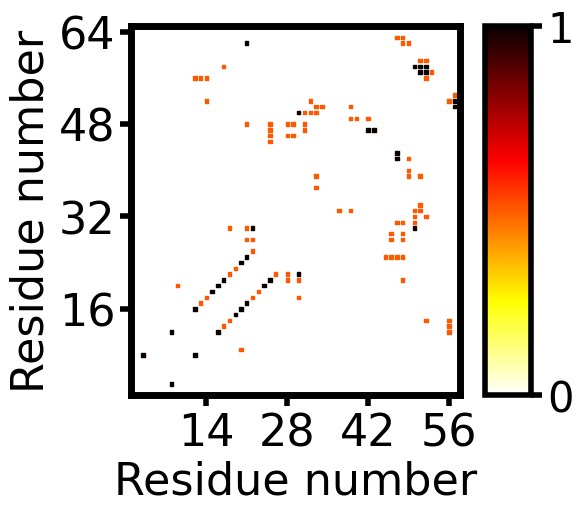

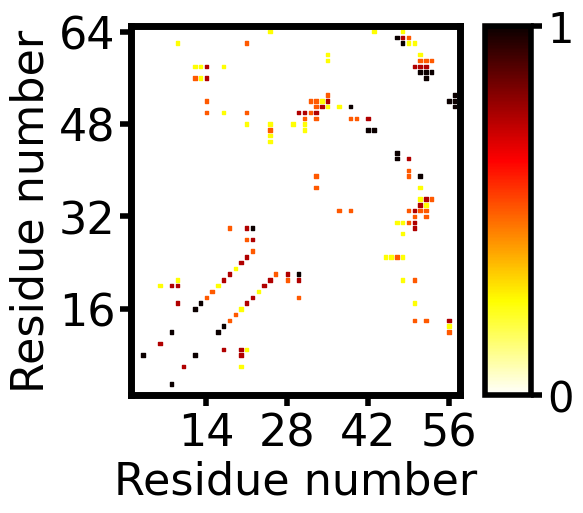

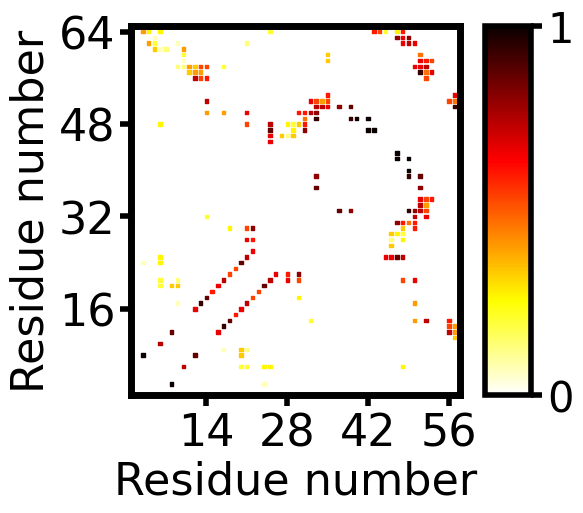

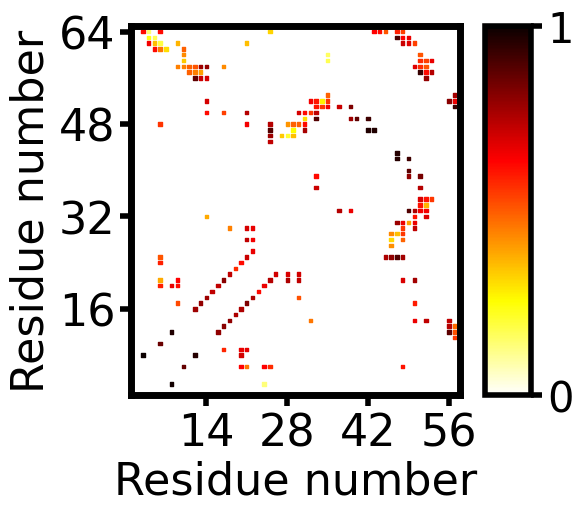

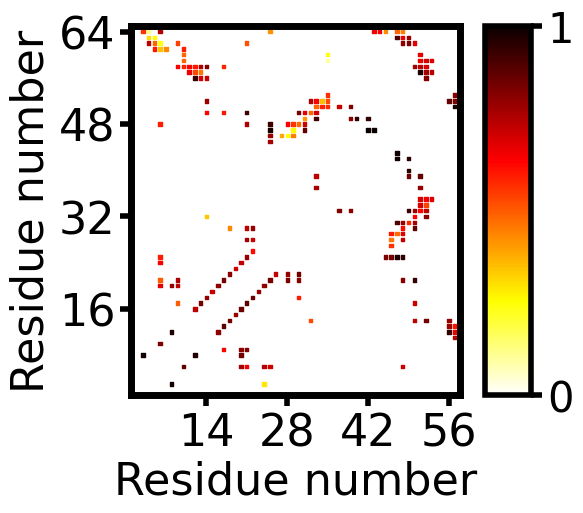

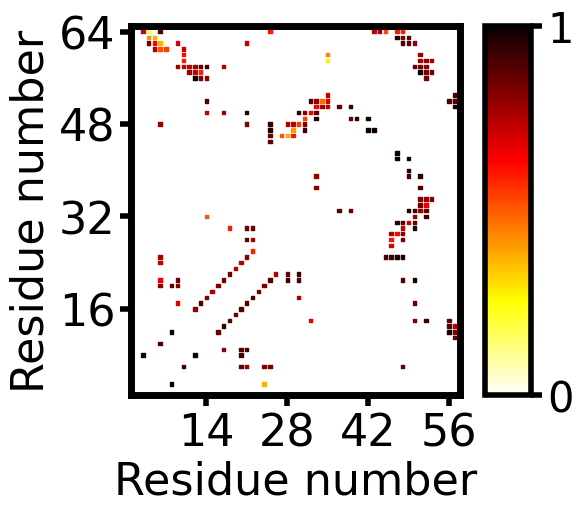

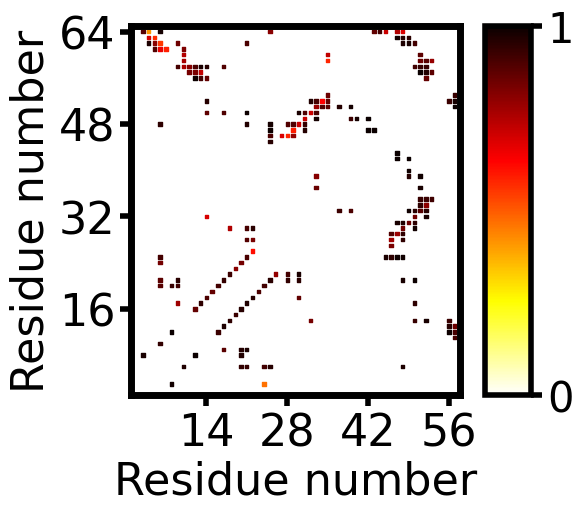

In [116]:
print ("Contacting pairs array shape (No.of.frames x No.of.pairs):",dists.shape)
print ("Q array shape (same as no.of.frames):",Q.shape)

print (n_bins)
# 2-D array for Q-values and corresponding contacting pairs
pairs_hist=np.zeros((n_bins,total_contacts),dtype=int)
print ("ACM histogram array shape",pairs_hist.shape)

def acm_plot(X,Y,Z):
  fig,ax=plt.subplots(1,1)
  ax.set_aspect('1')
  plt.scatter(x=X,y=Y,c=Z,marker="s",s=6,cmap='hot_r')
  plt.scatter(x=Y,y=X,c=Z,marker="s",s=6,cmap='hot_r')
  plt.xlim([1,max(X)])
  plt.ylim([1,max(Y)])
  plt.clim([0,1])
  cbar=plt.colorbar(aspect='8')
  #cbar.set_label('-ln(P(%s,%s))'%tuple(L),fontsize=30)
  cbar.ax.tick_params(width=4,labelsize=30,length=8)
  cbar.set_ticks([0,1])
  cbar.outline.set_linewidth(4)
  ax.tick_params(width=4,labelsize=32,length=8)
  ax.set_xticks(range(max(X)//4,max(X),max(X)//4))
  ax.set_yticks(range(max(Y)//4,max(Y),max(Y)//4))
  for i in ['top','bottom','left','right']:
      ax.spines[i].set_linewidth(5)
  plt.xlabel("Residue number",fontsize=32)
  plt.ylabel("Residue number",fontsize=32)



# Contacting pairs frame and pair indices
frame_idx,pair_idx=np.where(dists<=1.2*native_dists)
# get bin index for the frames
bin_idx=Q_to_bins[frame_idx]
print ("Bin index array shape:",bin_idx.shape)
print ("Pair index array shape:",pair_idx.shape)

# add in histogram
np.add.at(pairs_hist,(bin_idx,pair_idx),1)

# plot
X,Y=native_pairs.T + 1 # adding 1
for j in range(1,n_bins):
  if Q_hist[j]==0: continue
  Z=pairs_hist[j]/Q_hist[j]
  acm_plot(X,Y,Z)

